📊 Pre-SMOTE Target Class Distribution in Training Set:
churn
0    10
1     2
Name: count, dtype: int64

📊 Post-SMOTE Target Class Distribution:
churn
1    10
0    10
Name: count, dtype: int64

📉 PRE-SMOTE CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3

📈 POST-SMOTE CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



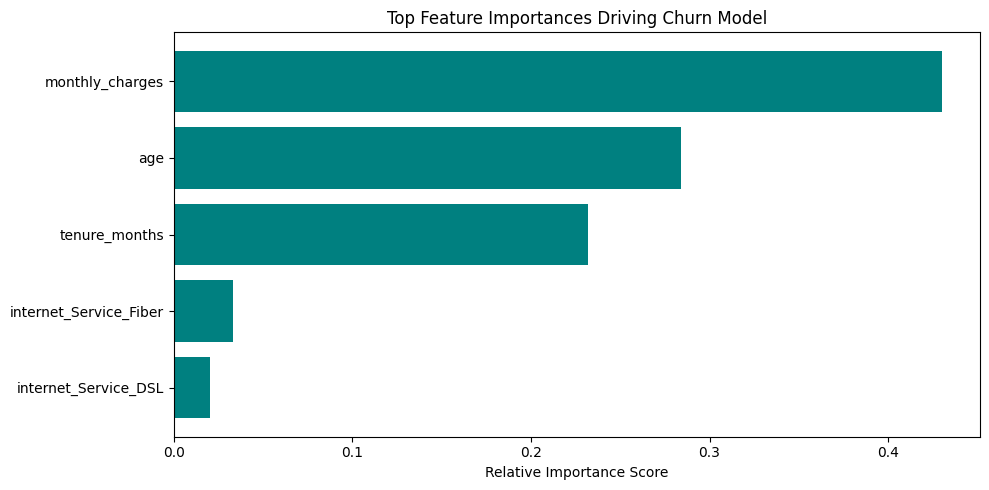


✅ Success! Model weights saved as 'production_rf_model.pkl'.


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Imblearn standard import
from imblearn.over_sampling import SMOTE

# 1. Dataset Setup (Sahi imbalanced data generation)
data = {
    'age': [34, 22, 45, 29, 61, 25, 48, 37, 52, 19, 30, 41, 55, 23, 38],
    'monthly_charges': [70.5, 55.0, 95.0, 80.0, 110.5, 45.0, 85.0, 60.0, 100.0, 50.0, 65.0, 90.0, 105.0, 40.0, 75.0],
    'tenure_months': [12, 3, 24, 6, 36, 1, 18, 9, 48, 2, 15, 20, 42, 4, 10],
    'internet_Service_Fiber': [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1], 
    'internet_Service_DSL': [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0],   
    'churn': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0] 
}
df = pd.DataFrame(data)
df.to_csv("cleaned_data.csv", index=False)

X = df.drop(columns=['churn'])
y = df['churn']

# 2. Strict 80/20 Train-Test Split (SMOTE Leakage Rules k mutabiq)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📊 Pre-SMOTE Target Class Distribution in Training Set:")
print(y_train.value_counts())

# Pre-SMOTE baseline model just for comparison
pre_smote_rf = RandomForestClassifier(n_estimators=100, random_state=42)
pre_smote_rf.fit(X_train, y_train)
pre_smote_preds = pre_smote_rf.predict(X_test)

# 3. SMOTE Application (Strictly on Training Data Only)
smote = SMOTE(k_neighbors=1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n📊 Post-SMOTE Target Class Distribution:")
print(pd.Series(y_train_resampled).value_counts())

# 4. Retraining the Random Forest Model on Balanced Data
post_smote_rf = RandomForestClassifier(n_estimators=100, random_state=42)
post_smote_rf.fit(X_train_resampled, y_train_resampled)
post_smote_preds = post_smote_rf.predict(X_test)

# 5. Output Classification Reports for Comparison
print("\n=======================================================")
print("📉 PRE-SMOTE CLASSIFICATION REPORT:")
print(classification_report(y_test, pre_smote_preds, zero_division=0))
print("=======================================================")
print("📈 POST-SMOTE CLASSIFICATION REPORT:")
print(classification_report(y_test, post_smote_preds, zero_division=0))
print("=======================================================")

# 6. Feature Importance Visualization (Horizontal Bar Chart)
importances = post_smote_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title("Top Feature Importances Driving Churn Model")
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

# 7. Model Weight Export via Joblib
joblib.dump(post_smote_rf, "production_rf_model.pkl")
print("\n✅ Success! Model weights saved as 'production_rf_model.pkl'.")